In [313]:
import matplotlib.pyplot as plt
import h5py
import numpy as np
import os
import torch as th

file_name = "/home/arpit/test_projects/mimicgen/random_files/arm_1.hdf5"
f = h5py.File(file_name, "r")

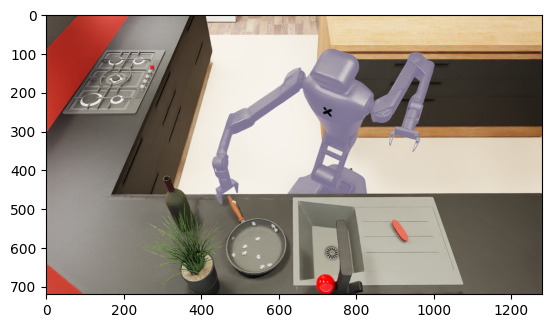

In [320]:
# np.array(f["data"]["demo_0"]["obs"]["robot_r1::robot_r1:left_eef_link:Camera:0::rgb"]).shape
i = 307
path = "/home/arpit/test_projects/mimicgen/paper_assets"
img = f["data"]["demo_0"]["obs"]["viewer_camera_img"][i]
plt.imsave(f'{path}/image_{i}.jpg', img)
plt.imshow(img)
plt.show()

In [328]:
og.sim.viewer_camera.horizontal_aperture = 25.0
# Set camera
og.sim.viewer_camera.set_position_orientation(
    position=th.tensor([ 5.473, -2.686,  2.403]),
    orientation=th.tensor([ 0.364, -0.004, -0.004,  0.932])
)
for _ in range(10): og.sim.step()

In [326]:
for _ in range(200): og.sim.step()

In [333]:
import matplotlib.pyplot as plt
# og.sim.viewer_camera.image_width
viewer_camera_img = og.sim.viewer_camera.get_obs()[0]["rgb"][:, :, :3]
# plt.imshow(viewer_camera_img)
# plt.show()
plt.imsave(f'{path}/base3.jpg', viewer_camera_img.numpy())


In [ ]:
np.array(f["data"]["demo_0"]["obs"]["robot_r1::robot_r1:left_eef_link:Camera:0::rgb"]).shape

In [ ]:
import json
import h5py
import random
import logging
import omnigibson as og
import torch as th
th.set_printoptions(precision=3, sci_mode=False)
import numpy as np
np.set_printoptions(precision=3, suppress=True)
from omnigibson.macros import create_module_macros
from omnigibson.action_primitives.starter_semantic_action_primitives import StarterSemanticActionPrimitives
import omnigibson.utils.transform_utils as T
from scipy.spatial.transform import Rotation as R
import omnigibson.lazy as lazy
from omnigibson import object_states
from omnigibson.objects.primitive_object import PrimitiveObject
from omnigibson.objects.dataset_object import DatasetObject
import mimicgen.utils.file_utils as MG_FileUtils

def flatten_obs(obs):
    flat_obs = {}

    for top_key, top_val in obs.items():
        if isinstance(top_val, dict):
            for cam_key, cam_val in top_val.items():
                if isinstance(cam_val, dict):
                    for data_key, data_val in cam_val.items():
                        new_key = f"{top_key}::{cam_key}::{data_key}"
                        flat_obs[new_key] = data_val
                else:
                    # In case it's not a dict, fallback to one level key
                    new_key = f"{top_key}::{cam_key}"
                    flat_obs[new_key] = cam_val
        else:
            pass

    return flat_obs

def get_obs(env, robot):
    obs, info = env.get_obs()
    obs = flatten_obs(obs)

    viewer_camera_img = og.sim.viewer_camera.get_obs()[0]["rgb"][:, :, :3]
    obs.update({'viewer_camera_img': viewer_camera_img})

    for k in obs.keys():
        if "seg" in k:
            obs[k] = obs[k].cpu()
        else:
            obs[k] = obs[k]
    return obs, info

seed = 0
random.seed(seed)
np.random.seed(seed)
th.manual_seed(seed)

# Load the scene from the hdf5 file
f = h5py.File("/home/arpit/test_projects/OmniGibson/teleop_collected_data/r1_clean_pan.hdf5", "r")
config = f["data"].attrs["config"]
config = json.loads(config)

# Custom changes
config["scene"]["load_room_instances"] = ["kitchen_0", "dining_room_0", "entryway_0", "living_room_0"]
config["robots"][0]["position"] = [0.0, 0.0, 0.0]
config["robots"][0]["orientation"] = [0.0, 0.0, 0.0, 1.0]

RESOLUTION = (256, 256)

# Explicity add the depth_linear and rgb modalities
config["robots"][0]["obs_modalities"].append("depth_linear")
config["robots"][0]["obs_modalities"].append("rgb")
config["robots"][0]["obs_modalities"].append("seg_instance")

# Setting the camera height and width here because setting it later causes issues
config["robots"][0]["sensor_config"]["VisionSensor"]["sensor_kwargs"]["image_height"] = RESOLUTION[0]
config["robots"][0]["sensor_config"]["VisionSensor"]["sensor_kwargs"]["image_width"] = RESOLUTION[1]
config["robots"][0]["sensor_config"]["VisionSensor"]["sensor_kwargs"]["horizontal_aperture"] = 25.0

robot_reset_pos = "tuck"
if robot_reset_pos == "untuck":
    config["robots"][0]["reset_joint_pos"] = [
            0.0000,
            0.0000,
            0.000,
            0.000,
            0.000,
            -0.0000, # 6 virtual base joint 
             0.5,
            -1.0,
            -0.8,
            -0.0000, # 4 torso joints
            -0.000,
            0.000,
            1.8944,
            1.8945,
            -0.9848,
            -0.9849,
            1.5612,
            1.5621,
            0.9097,
            0.9096,
            -1.5544,
            -1.5545,
            0.0500,
            0.0500,
            0.0500,
            0.0500,
        ]
elif robot_reset_pos == "tuck":
    # Tucked reset joint positions. The torso is different from the default R1 tucked position
    config["robots"][0]["reset_joint_pos"] = [
            0.0000,
            0.0000,
            0.000,
            0.000,
            0.000,
            -0.0000, # 6 virtual base joint 
             0.5,
            -1.0,
            -0.8,
            -0.0000, # 4 torso joints
            0.0, # left arm joint 1
            0.0, # right arm joint 1
            0.0,
            0.0,
            -0.15,
            -0.15,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0500,
            0.0500,
            0.0500,
            0.0500,
        ] 

env = og.Environment(configs=config)
robot = env.robots[0]
env.reset()

# remove later
obs, info = env.get_obs()

# Set camera
og.sim.viewer_camera.horizontal_aperture = 25.0
og.sim.viewer_camera.set_position_orientation(
    position=th.tensor([ 5.473, -2.686,  2.403]),
    orientation=th.tensor([ 0.364, -0.004, -0.004,  0.932])
)

# Add/Remove objects
obj = env.scene.object_registry("name", "fixed_window_glimdy_0")
obj.visible = False
for eef_link_name in robot.eef_link_names.values():
    robot.links[eef_link_name].visual_meshes["VisualSphere"].visible = False

# Action Diversity: Load 1 pan and three different base pose
pan = env.scene.object_registry("name", "frying_pan_602")
pan.set_position_orientation(th.tensor([5.2, -2.0, 0.908]), th.tensor([    -0.000,      0.000,     -0.499,      0.866]))

# Load distractor objects
# broom-tpyvbt
# mop-qclfvj
distractor_objects = []
obj = DatasetObject(
    name="mop",
    category="mop",
    model="qclfvj",
)
distractor_objects.append(obj)
obj = DatasetObject(
    name="pot_plant",
    category="pot_plant",
    model="cqqyzp",
    scale=th.tensor([1.3, 1.3, 1.3]),
)
distractor_objects.append(obj)
obj = DatasetObject(
    name="wine_bottle",
    category="wine_bottle",
    model="inkqch",
    scale=th.tensor([1.4, 1.4, 1.7])
)
distractor_objects.append(obj)

# Load the objects into the scene
state = og.sim.dump_state()
og.sim.stop()
# Load the objects into the scene
og.sim.batch_add_objects(distractor_objects, [env.scene] * len(distractor_objects))
og.sim.play()
og.sim.load_state(state)

# Set object pose to ensure no collision at spawn time
x_pos = 5.0
for distractor_object in distractor_objects:
    x_pos += 1.0
    distractor_object.set_position_orientation(position=th.tensor([x_pos,  0.0,  0.0]))
og.sim.step()

# obj.set_position_orientation(th.tensor([ 5.318, -1.418,  0.267]), th.tensor([-0.002, -0.001,  0.938,  0.347]))

# Change the color of the robot to be black.
for material in robot.materials:
    material.diffuse_color_constant = th.tensor([0.0, 0.0, 0.0])

# loop over base pose sampling and choose 3 that you like
primitive = StarterSemanticActionPrimitives(
                env,
                env.robots[0],
                enable_head_tracking=False,
                curobo_batch_size=6,
                curobo_use_cuda_graph=False,
                use_base_pose_hack=False,
                real_robot_mode=False,
            )

In [189]:
# Set camera
og.sim.viewer_camera.set_position_orientation(
    position=th.tensor([ 5.505, -2.686,  2.403]),
    orientation=th.tensor([ 0.404, -0.005, -0.006,  0.915])
)
for _ in range(10): og.sim.step()

In [334]:
pan.set_position_orientation(th.tensor([5.2, -2.0, 0.908]) + th.tensor([0.1, 0.1, 0.0]), th.tensor([    -0.000,      0.000,     -0.499,      0.866]))

mop = env.scene.object_registry("name", "mop")
orientation = th.tensor([-0.002, -0.001,  0.938,  0.347])
rot_z = R.from_euler('z', 40, degrees=True)
original_rot = R.from_quat(orientation)
new_rot = rot_z * original_rot
rotated_quat = new_rot.as_quat()
mop.set_position_orientation(th.tensor([ 5.218, -1.418,  0.267]) + th.tensor([0.1, -0.1, 0.0]), rotated_quat)

pot_plant = env.scene.object_registry("name", "pot_plant")
# pot_plant.set_position_orientation(th.tensor([ 5.072, -2.083,  1.083]), th.tensor([    -0.000,     -0.000,      0.953,      0.303]))
pot_plant.set_position_orientation(th.tensor([ 5.1, -2.1,  1.083]), th.tensor([    -0.000,     -0.000,      0.953,      0.303]))

wine_bottle = env.scene.object_registry("name", "wine_bottle")
wine_bottle.set_position_orientation(th.tensor([ 4.938, -1.772,  1.079]), th.tensor([    -0.000,      0.000,     -0.997,      0.079]))

In [167]:
distractor_objects = []
obj = DatasetObject(
    name="trash_can",
    category="trash_can",
    model="vasiit",
    scale=th.tensor([1.2, 1.2, 1.7]),
)
distractor_objects.append(obj)

state = og.sim.dump_state()
og.sim.stop()
# Load the objects into the scene
og.sim.batch_add_objects(distractor_objects, [env.scene] * len(distractor_objects))
og.sim.play()
og.sim.load_state(state)

# Set object pose to ensure no collision at spawn time
x_pos = 5.0
for distractor_object in distractor_objects:
    x_pos += 1.0
    distractor_object.set_position_orientation(position=th.tensor([x_pos,  0.0,  0.0]))
og.sim.step()

In [335]:
# mop.set_position_orientation(position=th.tensor([0.0, 0.0, 0.0]))
for _ in range(50): og.sim.step()

In [265]:
# trash_can = env.scene.object_registry("name", "trash_can")
# position 1
# trash_can.set_position_orientation(position=th.tensor([ 5.805, -0.964, 0.336]), orientation=th.tensor([-0.014,  0.008, -0.607,  0.794]))
# # position 2
# trash_can.set_position_orientation(position=th.tensor([ 4.996, -0.871, 0.336]), orientation=th.tensor([-0.014,  0.008, -0.607,  0.794]))

# obj.states[object_states.OnTop].set_value(other=env.scene.object_registry("name", "floors_kxcpgy_0"), new_value=True)
# trash_can.set_position_orientation(position=th.tensor([ 0.0, 0.0, 0.336]), orientation=th.tensor([-0.014,  0.008, -0.607,  0.794]))

# lamp = env.scene.object_registry("name", "floor_lamp")
# lamp.states[object_states.OnTop].set_value(other=env.scene.object_registry("name", "floors_kxcpgy_0"), new_value=True)

# lamp.set_position_orientation(th.tensor([5.018, -1.418,  0.2673]), th.tensor([    -0.000,      0.000,      0.647,      0.762]))

# for _ in range(20): og.sim.step()


In [243]:
# distractor_objects = []
# obj = DatasetObject(
#     name="floor_lamp",
#     category="floor_lamp",
#     model="vdxlda",
#     scale=th.tensor([1.0, 1.0, 1.5]),
# )
# distractor_objects.append(obj)

# state = og.sim.dump_state()
# og.sim.stop()
# # Load the objects into the scene
# og.sim.batch_add_objects(distractor_objects, [env.scene] * len(distractor_objects))
# og.sim.play()
# og.sim.load_state(state)

# # Set object pose to ensure no collision at spawn time
# x_pos = 5.0
# for distractor_object in distractor_objects:
#     x_pos += 1.0
#     distractor_object.set_position_orientation(position=th.tensor([x_pos,  0.0,  0.0]))
# og.sim.step()

In [171]:
# state = og.sim.dump_state()
# og.sim.stop()
# trash_can.scale = th.tensor([1.2, 1.2, 1.7])
# og.sim.play()
# og.sim.load_state(state)
# for _ in range(50): og.sim.step()
# wine_bottle.set_position_orientation(th.tensor([ 4.838, -1.872,  1.279]), th.tensor([    -0.000,      0.000,     -0.997,      0.079]))
# for _ in range(50): og.sim.step()


In [246]:
for _ in range(200): og.sim.step()

In [247]:
# lamp.get_position_orientation()

(tensor([9.108, 1.587, 1.173]),
 tensor([    -0.000,      0.000,      0.647,      0.762]))

In [332]:

# =========== Finding robot base pose ============
eef_pose = {'right': (
        th.tensor([[ 5.046, -1.725,  1.092],
    [ 5.036, -1.713,  1.016],
    [ 5.077, -1.700,  0.985],
    [ 5.034, -1.684,  0.973],
    [ 5.061, -1.707,  0.975],
    [ 5.081, -1.705,  0.941],
    [ 5.090, -1.705,  0.948],
    [ 5.220, -1.736,  1.046]]) + th.tensor([0.1, 0.1, 0.0]), 
        th.tensor([[ 0.927, -0.357,  0.071,  0.089],
    [ 0.926, -0.370,  0.068,  0.044],
    [ 0.933, -0.346,  0.094, -0.025],
    [ 0.916, -0.390,  0.090, -0.015],
    [ 0.933, -0.351,  0.079, -0.014],
    [ 0.933, -0.347,  0.091, -0.036],
    [ 0.916, -0.388,  0.092, -0.049],
    [ 0.800, -0.590,  0.110, -0.017]])
)}
# for _ in range(1):
#     base_pose2d = primitive._sample_pose_near_object(pan, eef_pose, skip_obstacle_update=False, visibility_constraint=False)
#     if base_pose2d is None:
#         continue
#     base_pose = primitive._get_robot_pose_from_2d_pose(base_pose2d)
#     base_pose
#     robot.set_position_orientation(base_pose[0], base_pose[1])
#     for _ in range(10): og.sim.step()
#     breakpoint()

import seaborn as sns
palette = sns.color_palette("deep")    
robot.highlighted = True

# =========== Setting robot base pose ============
# # Base pose 1 (middle)
# robot.set_highlight_properties(color=list(palette[0]), intensity=1000.0) 
# base_pose = (th.tensor([ 5.254, -0.980, -0.019]), th.tensor([ 0.005, -0.002, -0.727,  0.686]))

# # Base pose 2 (left)
# robot.set_highlight_properties(color=list(palette[2]), intensity=1000.0)
# base_pose_type = "left"
# base_pose = (th.tensor([ 4.796, -1.171, -0.019]), th.tensor([     0.005,      0.000,     -0.444,      0.896]))
# original_quat = th.tensor([ 0.005,      0.000,     -0.444,      0.896])
# rot_z = R.from_euler('z', 20, degrees=True)
# original_rot = R.from_quat(original_quat)
# new_rot = rot_z * original_rot
# rotated_quat = new_rot.as_quat()
# base_pose = (th.tensor([ 4.796, -1.171, -0.019]), th.tensor([     0.005,      0.000,     -0.444,      0.896]))

# Base pose 3 (right)
robot.set_highlight_properties(color=list(palette[3]), intensity=1000.0) 
base_pose_type = "right"
base_pose = (th.tensor([ 5.605, -1.164, -0.019]) + th.tensor([0.3, 0.0, 0.0]), th.tensor([ 0.004, -0.003, -0.882,  0.471]))
original_quat = th.tensor([ 0.004, -0.003, -0.882,  0.471])
rot_z = R.from_euler('z', 0, degrees=True) # originally 0
original_rot = R.from_quat(original_quat)
new_rot = rot_z * original_rot
rotated_quat = new_rot.as_quat()
base_pose = (th.tensor([ 5.605, -1.164, -0.019]) + th.tensor([0.2, 0.0, 0.0]), th.tensor(rotated_quat))

robot.set_position_orientation(base_pose[0], base_pose[1])
for _ in range(10): og.sim.step()
# ==================================================

In [89]:
# for _ in range(200): og.sim.step()
base_pose_type

'left'

In [20]:
seed = 1
random.seed(seed)
np.random.seed(seed)
th.manual_seed(seed)

In [ ]:
if base_pose_type == "right":
    target_pos = {'right_eef_link': th.tensor([ 5.046, -1.725,  1.092]) + th.tensor([0.1, 0.1, -0.17])} 
    target_quat = {'right_eef_link': th.tensor([ 0.927, -0.357,  0.071,  0.089])}
elif base_pose_type == "left":
    target_pos = {'right_eef_link': th.tensor([ 5.046, -1.725,  1.092]) + th.tensor([0.0, 0.0, 0.03])} 
    target_quat = {'right_eef_link': th.tensor([ 0.927, -0.357,  0.071,  0.089])}   

emb_sel = "arm_no_torso"
new_target_pos = {k: th.stack([v for _ in range(primitive._motion_generator.batch_size)]) for k, v in target_pos.items()}
new_target_quat = {k: th.stack([v for _ in range(primitive._motion_generator.batch_size)]) for k, v in target_quat.items()}
mp_results, traj_paths = primitive._motion_generator.compute_trajectories(
    target_pos=new_target_pos,
    target_quat=new_target_quat,
    is_local=False,
    max_attempts=50,
    timeout=60.0,
    ik_fail_return=10,
    enable_finetune_trajopt=True,
    finetune_attempts=1,
    return_full_result=True,
    success_ratio=1.0 / primitive._motion_generator.batch_size,
    attached_obj=None,
    attached_obj_scale=None,
    emb_sel=emb_sel,
    eyes_target_pos=None,
    eyes_target_quat=None,
)
successes = mp_results[0].success 
print("Arm MP successes: ", successes)
success_idx = th.where(successes)[0].cpu()
if len(success_idx) == 0:
    breakpoint()
else:
    traj_path = traj_paths[success_idx[0]]

In [306]:
# for i in range(6): logging.warning(len(traj_paths[i]))
successes

tensor([True, True, True, True, True, True], device='cuda:0')

In [299]:
# import seaborn as sns
# palette = sns.color_palette("deep")    
# robot.highlighted = True
# robot.set_highlight_properties(color=list(palette[4]), intensity=1000.0) 
for _ in range(10): og.sim.step()

In [307]:
# traj_path = traj_paths[0]
use_arm = "right"
q_traj = primitive._motion_generator.path_to_joint_trajectory(traj_path, get_full_js=True, emb_sel=emb_sel)
q_traj = th.stack(primitive._add_linearly_interpolated_waypoints(plan=q_traj, max_inter_dist=0.01))
q_traj = q_traj.cpu()
mp_actions = []
for j_pos in q_traj:
    if use_arm == "right":
        j_pos[robot.arm_control_idx["left"]] = robot.get_joint_positions()[robot.arm_control_idx["left"]]
    elif use_arm == "left":
        j_pos[robot.arm_control_idx["right"]] = robot.get_joint_positions()[robot.arm_control_idx["right"]]

    action = robot.q_to_action(j_pos).cpu().numpy()
    mp_actions.append(action)

In [308]:
# breakpoint()
original_state = og.sim.dump_state(serialized=True)
states, actions, observations, observations_info = [], [], [], []
for i, mp_action in enumerate(mp_actions):
    state = og.sim.dump_state(serialized=True)
    obs, obs_info = get_obs(env, robot)
    # TODO: Check if we can use primtiive stack execute action here. This will allow for checking convergence errors etc.
    env.step(mp_action)
    states.append(state)
    actions.append(mp_action)
    observations.append(obs)
    observations_info.append(json.dumps(obs_info))

In [309]:
tmp_dataset_folder_path = "/home/arpit/test_projects/mimicgen/random_files"
MG_FileUtils.write_demo_to_hdf5(
    folder=tmp_dataset_folder_path,
    env=None,
    initial_state=dict(state=states[0]),
    states=states,
    observations=observations,
    observations_info=None,
    datagen_info=None,
    actions=np.array(actions),
)


In [321]:
og.sim.load_state(original_state, serialized=True)
for _ in range(50): og.sim.step()

In [ ]:
#Joint positions:

# 1. 
# Saved in hdf5 file: 100, 200, 307


# 2.  
# a) (Pdb) robot.get_joint_positions()
# tensor([ 5.3450e-05, -2.6224e-05,  3.7647e-03,  8.9554e-03,  4.6880e-03,
#         -5.9596e-05,  6.9947e-03,  3.8583e-03,  1.8381e-03, -8.7446e-03,
#          5.0046e-04,  1.0726e+00,  1.8178e-02,  2.6133e+00, -2.9410e-07,
#         -8.6613e-01, -1.4325e-02,  4.9755e-02, -1.2898e-03, -1.1976e+00,
#         -9.9132e-02, -4.0184e-02,  5.0000e-02,  4.9999e-02,  5.0000e-02,
#          5.0000e-02])

# b) (Pdb) robot.get_joint_positions()
# tensor([ 6.5203e-05, -2.6154e-05,  3.7648e-03,  8.9561e-03,  4.6875e-03,
#         -5.6478e-05,  8.9186e-03,  6.5238e-03,  1.9789e-03, -9.2047e-03,
#          5.0162e-04,  5.3618e-01,  2.0758e-02,  2.9583e+00, -7.0783e-07,
#         -2.1831e+00, -2.0085e-02,  4.7588e-02, -1.4256e-03, -1.1935e+00,
#         -9.9422e-02, -3.9063e-02,  5.0000e-02,  4.9999e-02,  5.0000e-02,
#          5.0000e-02])

# c) I don't have